In [1]:
from pyslfp import FingerPrint, IceModel, plot

# Sea Surface Height

Definition of sea surface

Definition of sea level

The response space of the sea level fingerprint from a direct load, $\zeta$, is ($SL, \mathbf{u}, \phi, \omega$).

The equation for 

## Implementation in pyslfp

This was implemented into the pyslfp library.

First a load is generated, in this case a load across all ice sheets, normalised to produce 1mm of GMSL change.

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x145ec1970>)

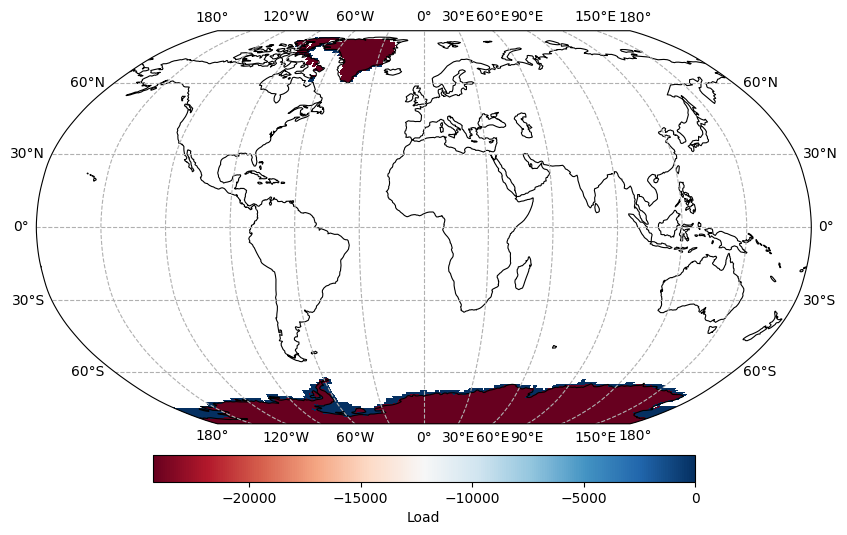

In [2]:
fp = FingerPrint(lmax=256)
fp.set_state_from_ice_ng(version=IceModel.ICE7G, date=0.0)

load = fp.direct_load_from_ice_thickness_change(
    fp.ice_projection(value=0)
)
load /= fp.mean_sea_level_change(
    direct_load=load
)  # normalise to 1mm GMSL change

plot(load * fp.ice_projection(), colorbar_label="Load")

A finger print response can then be generated from this load and then passed to the sea surface height:

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x146331eb0>)

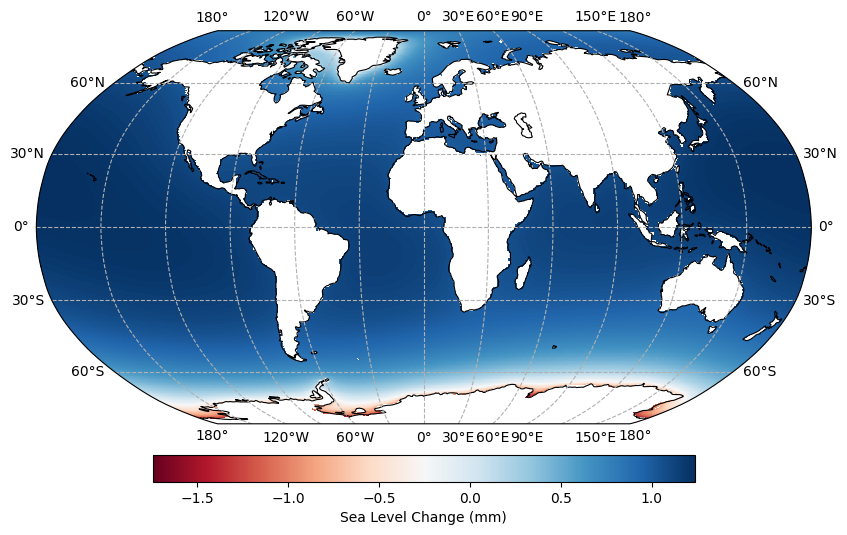

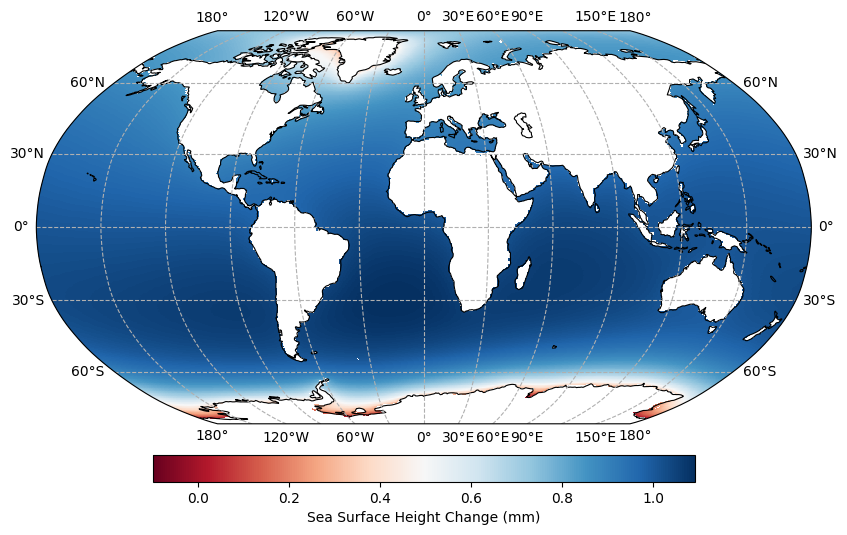

In [3]:
from pyshtools.constants.Callisto import angular_velocity

slc, dis, _, avc = fp(direct_load=load)

plot(
    slc * fp.ocean_projection(),
    colorbar_label="Sea Level Change (mm)",
)

sshc = fp.sea_surface_height_change(slc, dis, avc)

plot(
    sshc * fp.ocean_projection(),
    colorbar_label="Sea Surface Height Change (mm)",
)

When sampling altimetry data, however, typically the range of measurements is limited to within 66 degrees N/S, which can be implemented.

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x1466684d0>)

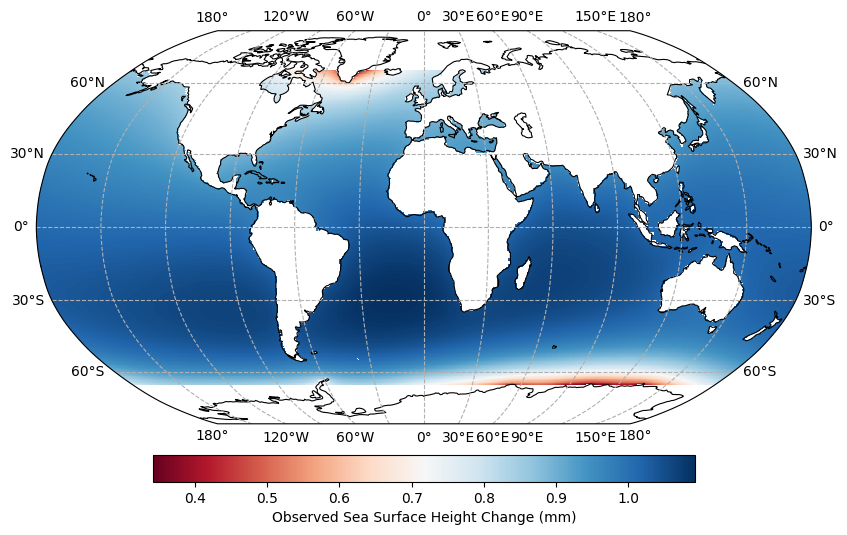

In [4]:
observed_sshc = sshc * fp.altimetry_projection(
    latitude_min=-66.0, latitude_max=66.0
)

plot(
    observed_sshc,
    colorbar_label="Observed Sea Surface Height Change (mm)",
)

Often GMSL estimates use SSHC surface averages to approximate averaging SLC, however errors are associated with this method. 

To simply show the error at this stage, we can take the surface average across the oceans for both and compare these values:

In [5]:
true_gmsl = fp.ocean_average(slc)
ssh_gmsl = fp.ocean_average(sshc)
estimated_gmsl = fp.integrate(sshc) / fp.integrate(
    fp.altimetry_projection(value=0)
)

percentage_error = (
    100 * abs(true_gmsl - estimated_gmsl) / abs(true_gmsl)
)

print(f"True GMSL change (using SLC): {true_gmsl:.3f} mm")
print(f"GMSL change using SSHC: {ssh_gmsl:.3f} mm")
print(
    f"Estimated GMSL change from observations: {estimated_gmsl:.3f} mm"
)
print(f"Percentage error: {percentage_error:.2f}%")

True GMSL change (using SLC): 1.000 mm
GMSL change using SSHC: 0.967 mm
Estimated GMSL change from observations: 1.388 mm
Percentage error: 38.82%


## Gaussian Operators



In [6]:
fp_op = fp.as_sobolev_linear_operator(
    2, fp.mean_sea_floor_radius * 0.1
)

To explore how 

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x1466d08f0>)

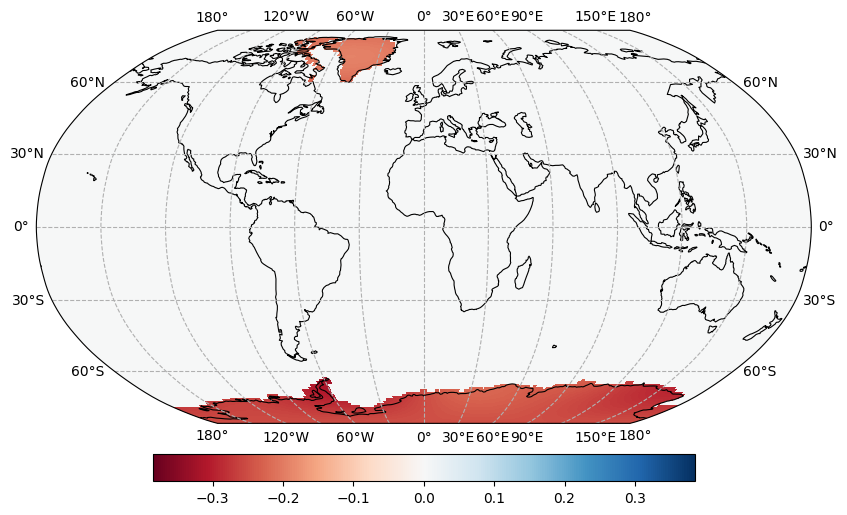

In [7]:
from pyslfp_extras.ice_thickness import IceSheetChange


ice_change = IceSheetChange.global_ice(
    finger_print=fp,
    finger_print_operator=fp_op,
    length_scale=0.2 * fp.mean_sea_floor_radius,
    pattern=IceSheetChange.UniformPattern(),
    ice_gmsl_std=0.001,
    gmsl_target_mean=0.01,
)
ice_thickness_measure = ice_change.ice_thickness

plot(ice_thickness_measure.sample(), symmetric=True)

We can confirm that this has the specified GMSL values. The operator that maps from ice thickness change to GMSL is provided by the IceSheetChange class.

In [8]:
from pygeoinf_extras import standard_dev, expectation

true_gmsl = ice_thickness_measure.affine_mapping(
    operator=ice_change.ice_thickness_to_gmsl_operator
)

print(
    f"Expectation of true GMSL: {expectation(true_gmsl):.3e} mm"
)
print(
    f"Standard deviation of true GMSL: {standard_dev(true_gmsl):.3e} mm"
)

Expectation of true GMSL: 9.951e-03 mm
Standard deviation of true GMSL: 9.982e-04 mm


Under the hood, the IceSheetChange class also provides the SLC and SSHC fields:

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: >,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x146a90470>)

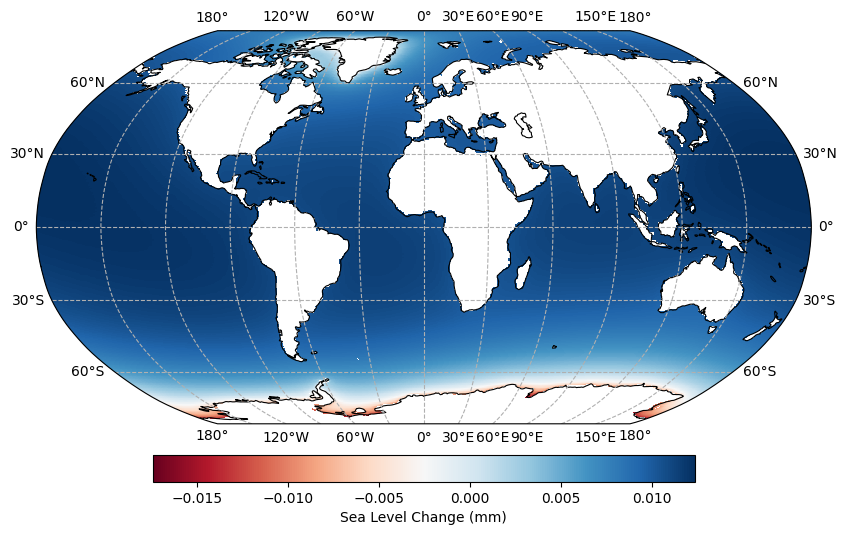

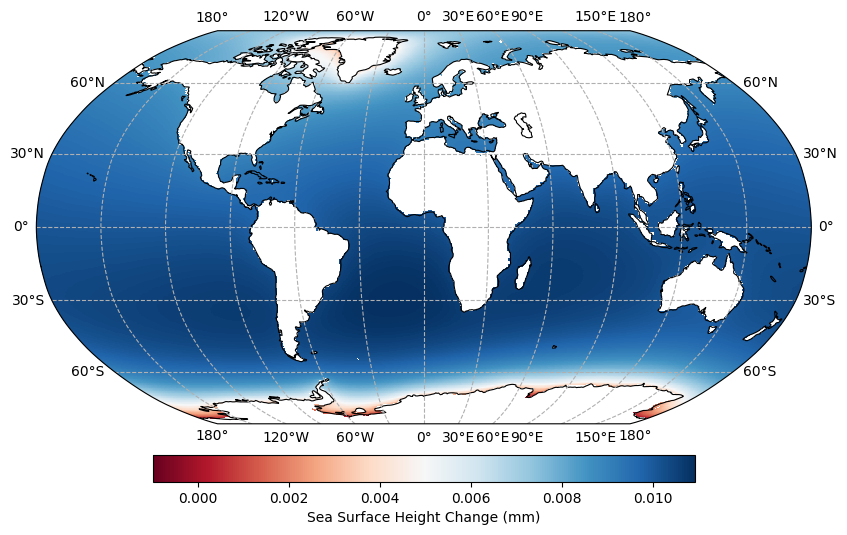

In [9]:
slc = ice_change.ice_slc
sshc = ice_change.ice_ssh

plot(
    slc.expectation * fp.ocean_projection(),
    colorbar_label="Sea Level Change (mm)",
)
plot(
    sshc.expectation * fp.ocean_projection(),
    colorbar_label="Sea Surface Height Change (mm)",
)

We can then estimate the GMSL differnce between the 

In [10]:
from pyslfp import averaging_operator

altimetry_operator = averaging_operator(
    sshc.domain,
    [
        fp.altimetry_projection(value=0)
        / fp.integrate(fp.altimetry_projection(value=0))
    ],
)

estimated_gmsl_from_sshc = sshc.affine_mapping(
    operator=altimetry_operator
)

print(type(estimated_gmsl_from_sshc))

print(
    f"Expectation of GMSL change from SSHC: {expectation(estimated_gmsl_from_sshc):.3e} mm"
)
print(
    f"Standard deviation of GMSL change from SSHC: {standard_dev(estimated_gmsl_from_sshc):.3e} mm"
)

<class 'pygeoinf.gaussian_measure.GaussianMeasure'>
Expectation of GMSL change from SSHC: 9.831e-03 mm
Standard deviation of GMSL change from SSHC: 9.882e-04 mm


To compare the true and estimation GMSL measures, we can plot them:

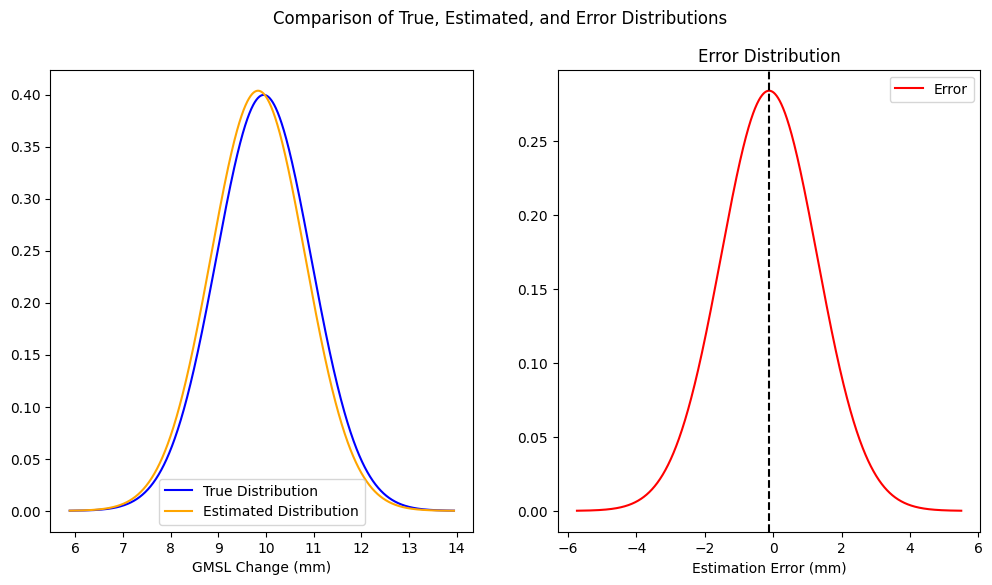

In [12]:
from project import error_plot

fig, (ax1, ax2) = error_plot(
    true_measure=true_gmsl * 1000,
    estimation_measure=estimated_gmsl_from_sshc * 1000,
    ax1_xlabel="GMSL Change (mm)",
    ax2_xlabel="Estimation Error (mm)",
)